# UCI HAR Dataset - Data Loading & Inspection

This notebook loads the UCI HAR dataset, prepares the train/test tensors, and performs a brief inspection of the data before using it for machine learning and deep learning models.


## Import Required Libraries

Import the libraries required for loading and processing the dataset.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from google.colab import files

In [2]:
uploaded = files.upload()

Saving human+activity+recognition+using+smartphones.zip to human+activity+recognition+using+smartphones.zip


## Load Dataset

Load the UCI HAR dataset and extract all inertial signal files.

In [3]:
!unzip "/content/human+activity+recognition+using+smartphones.zip"
!unzip "UCI HAR Dataset.zip"
!ls "UCI HAR Dataset/train/Inertial Signals"

Archive:  /content/human+activity+recognition+using+smartphones.zip
 extracting: UCI HAR Dataset.names   
 extracting: UCI HAR Dataset.zip     
Archive:  UCI HAR Dataset.zip
replace UCI HAR Dataset/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: UCI HAR Dataset/.DS_Store  
  inflating: __MACOSX/UCI HAR Dataset/._.DS_Store  
  inflating: UCI HAR Dataset/activity_labels.txt  
  inflating: __MACOSX/UCI HAR Dataset/._activity_labels.txt  
  inflating: UCI HAR Dataset/features.txt  
  inflating: __MACOSX/UCI HAR Dataset/._features.txt  
  inflating: UCI HAR Dataset/features_info.txt  
  inflating: __MACOSX/UCI HAR Dataset/._features_info.txt  
  inflating: UCI HAR Dataset/README.txt  
  inflating: __MACOSX/UCI HAR Dataset/._README.txt  
  inflating: UCI HAR Dataset/test/Inertial Signals/body_acc_x_test.txt  
  inflating: __MACOSX/UCI HAR Dataset/test/Inertial Signals/._body_acc_x_test.txt  
  inflating: UCI HAR Dataset/test/Inertial Signals/body_acc_y_test.txt  
  inflating:

## Load Training Sensor Signals

Load body acceleration and gyroscope signals from the training set.

In [4]:
acc_x = pd.read_csv(
    "UCI HAR Dataset/train/Inertial Signals/body_acc_x_train.txt",
    sep=r"\s+",
    header=None
)

acc_y = pd.read_csv(
    "UCI HAR Dataset/train/Inertial Signals/body_acc_y_train.txt",
    sep=r"\s+",
    header=None
)

acc_z = pd.read_csv(
    "UCI HAR Dataset/train/Inertial Signals/body_acc_z_train.txt",
    sep=r"\s+",
    header=None
)

gyro_x = pd.read_csv(
    "UCI HAR Dataset/train/Inertial Signals/body_gyro_x_train.txt",
    sep=r"\s+",
    header=None
)

gyro_y = pd.read_csv(
    "UCI HAR Dataset/train/Inertial Signals/body_gyro_y_train.txt",
    sep=r"\s+",
    header=None
)

gyro_z = pd.read_csv(
    "UCI HAR Dataset/train/Inertial Signals/body_gyro_z_train.txt",
    sep=r"\s+",
    header=None
)

In [5]:
print(acc_x.shape)
print(acc_y.shape)
print(acc_z.shape)

print(gyro_x.shape)
print(gyro_y.shape)
print(gyro_z.shape)

(7352, 128)
(7352, 128)
(7352, 128)
(7352, 128)
(7352, 128)
(7352, 128)


## Convert to NumPy Arrays

In [6]:
acc_x = acc_x.values
acc_y = acc_y.values
acc_z = acc_z.values

gyro_x = gyro_x.values
gyro_y = gyro_y.values
gyro_z = gyro_z.values

## Build Training Tensor

In [7]:
X_train = np.stack(
    [
        acc_x,
        acc_y,
        acc_z,
        gyro_x,
        gyro_y,
        gyro_z
    ],
    axis=2
)

## Load Activity Labels

In [8]:
y_train = pd.read_csv(
    "UCI HAR Dataset/train/y_train.txt",
    header=None
)

In [9]:
print(y_train.shape)
print(y_train[0].unique())
print(y_train[0].value_counts())

(7352, 1)
[5 4 6 1 3 2]
0
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64


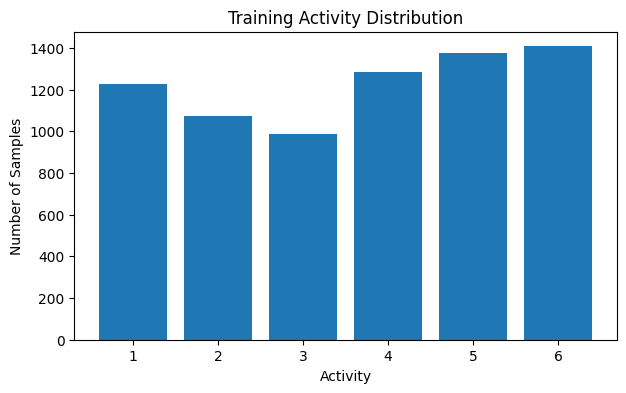

In [20]:
counts = y_train[0].value_counts().sort_index()

plt.figure(figsize=(7,4))
plt.bar(counts.index, counts.values)

plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.title("Training Activity Distribution")

plt.show()

## Load Total Acceleration

In [21]:
total_acc_x = pd.read_csv(
    "UCI HAR Dataset/train/Inertial Signals/total_acc_x_train.txt",
    sep=r"\s+",
    header=None
)

total_acc_y = pd.read_csv(
    "UCI HAR Dataset/train/Inertial Signals/total_acc_y_train.txt",
    sep=r"\s+",
    header=None
)

total_acc_z = pd.read_csv(
    "UCI HAR Dataset/train/Inertial Signals/total_acc_z_train.txt",
    sep=r"\s+",
    header=None
)

## Convert Total Acceleration Signals to NumPy Arrays

In [22]:
total_acc_x = total_acc_x.values
total_acc_y = total_acc_y.values
total_acc_z = total_acc_z.values

## Build the Final Training Tensor

Combine body acceleration, gyroscope, and total acceleration signals into a single input tensor for deep learning models.

In [23]:
X_train = np.stack(
    [
        acc_x,
        acc_y,
        acc_z,
        gyro_x,
        gyro_y,
        gyro_z,
        total_acc_x,
        total_acc_y,
        total_acc_z
    ],
    axis=2
)

## Inspect the Training Tensor

In [24]:
print("Training Tensor Shape:", X_train.shape)

Training Tensor Shape: (7352, 128, 9)


## Load Test Signals

In [25]:
acc_x_test = pd.read_csv(
    "UCI HAR Dataset/test/Inertial Signals/body_acc_x_test.txt",
    sep=r"\s+",
    header=None
)

acc_y_test = pd.read_csv(
    "UCI HAR Dataset/test/Inertial Signals/body_acc_y_test.txt",
    sep=r"\s+",
    header=None
)

acc_z_test = pd.read_csv(
    "UCI HAR Dataset/test/Inertial Signals/body_acc_z_test.txt",
    sep=r"\s+",
    header=None
)

gyro_x_test = pd.read_csv(
    "UCI HAR Dataset/test/Inertial Signals/body_gyro_x_test.txt",
    sep=r"\s+",
    header=None
)

gyro_y_test = pd.read_csv(
    "UCI HAR Dataset/test/Inertial Signals/body_gyro_y_test.txt",
    sep=r"\s+",
    header=None
)

gyro_z_test = pd.read_csv(
    "UCI HAR Dataset/test/Inertial Signals/body_gyro_z_test.txt",
    sep=r"\s+",
    header=None
)

## Convert Test Signals to NumPy Arrays

In [26]:
acc_x_test = acc_x_test.values
acc_y_test = acc_y_test.values
acc_z_test = acc_z_test.values

gyro_x_test = gyro_x_test.values
gyro_y_test = gyro_y_test.values
gyro_z_test = gyro_z_test.values

## Load Test Total Acceleration Signals

In [27]:
total_acc_x_test = pd.read_csv(
    "UCI HAR Dataset/test/Inertial Signals/total_acc_x_test.txt",
    sep=r"\s+",
    header=None
)

total_acc_y_test = pd.read_csv(
    "UCI HAR Dataset/test/Inertial Signals/total_acc_y_test.txt",
    sep=r"\s+",
    header=None
)

total_acc_z_test = pd.read_csv(
    "UCI HAR Dataset/test/Inertial Signals/total_acc_z_test.txt",
    sep=r"\s+",
    header=None
)

In [28]:
total_acc_x_test = total_acc_x_test.values
total_acc_y_test = total_acc_y_test.values
total_acc_z_test = total_acc_z_test.values

## Build the Final Test Tensor

In [29]:
X_test = np.stack(
    [
        acc_x_test,
        acc_y_test,
        acc_z_test,
        gyro_x_test,
        gyro_y_test,
        gyro_z_test,
        total_acc_x_test,
        total_acc_y_test,
        total_acc_z_test
    ],
    axis=2
)

In [30]:
y_test = pd.read_csv(
    "UCI HAR Dataset/test/y_test.txt",
    header=None
)

In [31]:
y_train = y_train.values
y_test = y_test.values

y_train = y_train - 1
y_test = y_test - 1

In [33]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("Classes:", np.unique(y_train))

X_train: (7352, 128, 9)
X_test : (2947, 128, 9)
y_train: (7352, 1)
y_test : (2947, 1)
Classes: [0 1 2 3 4 5]


## Visualize Body Acceleration Signals

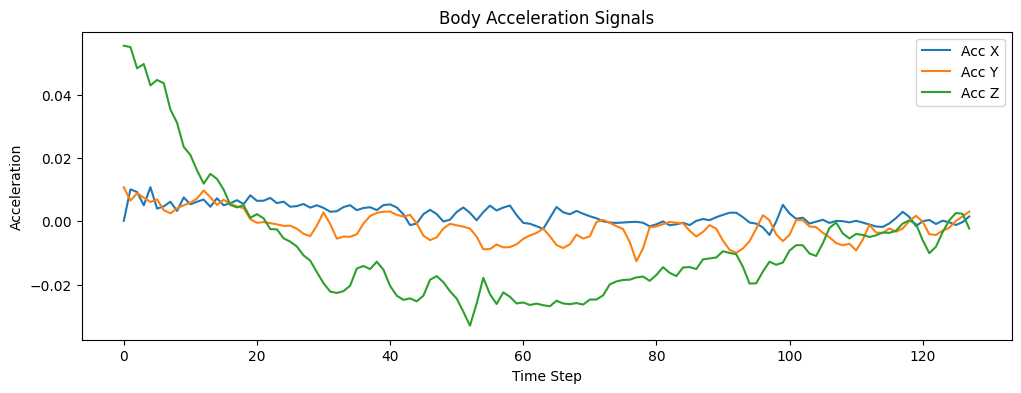

In [34]:
plt.figure(figsize=(12,4))

plt.plot(X_train[0,:,0], label="Acc X")
plt.plot(X_train[0,:,1], label="Acc Y")
plt.plot(X_train[0,:,2], label="Acc Z")

plt.title("Body Acceleration Signals")
plt.xlabel("Time Step")
plt.ylabel("Acceleration")
plt.legend()

plt.show()

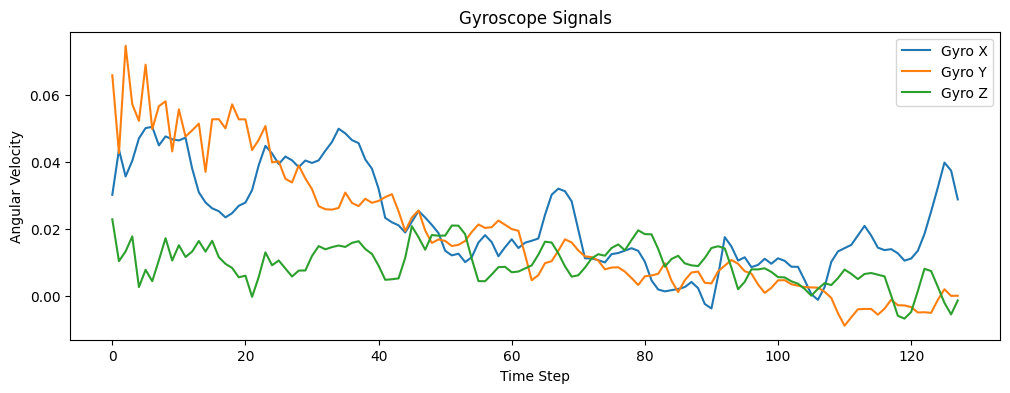

In [35]:
plt.figure(figsize=(12,4))

plt.plot(X_train[0,:,3], label="Gyro X")
plt.plot(X_train[0,:,4], label="Gyro Y")
plt.plot(X_train[0,:,5], label="Gyro Z")

plt.title("Gyroscope Signals")
plt.xlabel("Time Step")
plt.ylabel("Angular Velocity")
plt.legend()

plt.show()

## Summary

The UCI HAR dataset was successfully loaded and prepared for deep learning experiments.

The final dataset contains:

- 7352 training windows
- 2947 testing windows
- Window length of 128 time steps
- Nine sensor channels:
  - Body Acceleration (X, Y, Z)
  - Body Gyroscope (X, Y, Z)
  - Total Acceleration (X, Y, Z)

The prepared tensors are ready to be used by the deep learning models presented in the next notebook.